LEVEL 1 - TASK 1: DATA PREPROCESSING

STEP 1: SETUP PATHS
📁 Current directory: c:\Users\HP\Desktop\PDF\WORKSPACE\Projects\ML_Internship_Project\Level 1
📁 Dataset path: c:\Users\HP\Desktop\PDF\WORKSPACE\Projects\ML_Internship_Project\datasets\1) iris.csv
📁 Output directory: c:\Users\HP\Desktop\PDF\WORKSPACE\Projects\ML_Internship_Project\outputs
📁 Image directory: c:\Users\HP\Desktop\PDF\WORKSPACE\Projects\ML_Internship_Project\images

STEP 2: LOAD DATASET
✅ Loaded from: c:\Users\HP\Desktop\PDF\WORKSPACE\Projects\ML_Internship_Project\datasets\1) iris.csv

📌 DATASET SHAPE: 150 rows × 5 columns
📌 COLUMNS: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

📌 FIRST 5 ROWS:
   sepal_length  sepal_width  petal_length  petal_width species
0         5.100        3.500         1.400        0.200  setosa
1         4.900        3.000         1.400        0.200  setosa
2         4.700        3.200         1.300        0.200  setosa
3         4.600        3.100         1.500

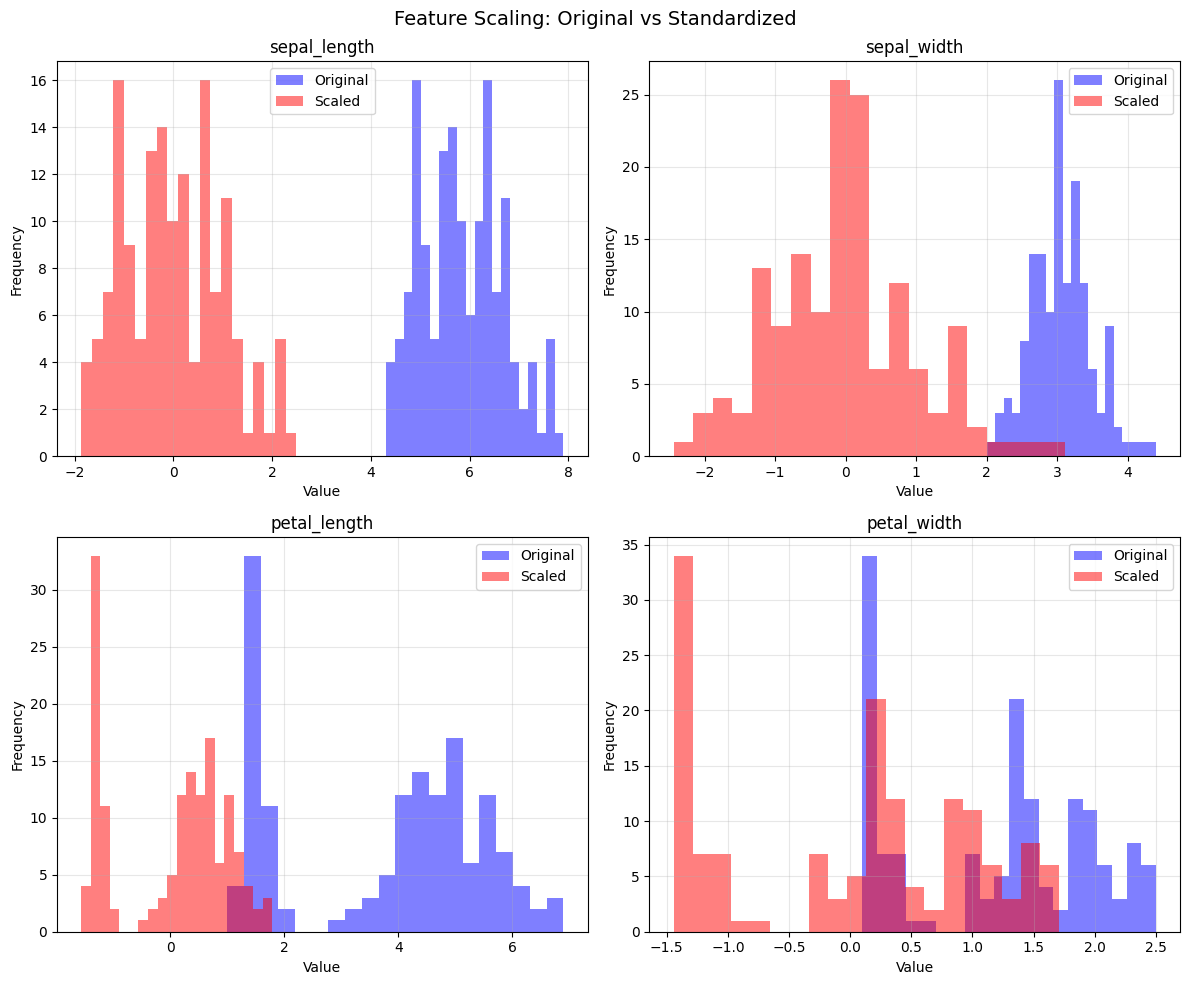

✅ Saved: c:\Users\HP\Desktop\PDF\WORKSPACE\Projects\ML_Internship_Project\images\scaling_visualization.png

STEP 7: SPLIT DATASET

📌 Training set: 120 samples (80%)
📌 Testing set: 30 samples (20%)
📌 Features: 4

📌 CLASS DISTRIBUTION:

Original dataset:
species_label
0   0.333
1   0.333
2   0.333
Name: proportion, dtype: float64

Training set:
species_label
0   0.333
1   0.333
2   0.333
Name: proportion, dtype: float64

Testing set:
species_label
0   0.333
1   0.333
2   0.333
Name: proportion, dtype: float64

STEP 8: SAVE PREPROCESSED DATA
✅ Saved to: c:\Users\HP\Desktop\PDF\WORKSPACE\Projects\ML_Internship_Project\outputs
   • iris_preprocessed.csv
   • X_train.csv
   • X_test.csv
   • y_train.csv
   • y_test.csv

STEP 9: SUMMARY

╔════════════════════════════════════════════════════════════════════════════╗
║                    LEVEL 1 - TASK 1 COMPLETED                             ║
╠════════════════════════════════════════════════════════════════════════════╣
║                      

In [1]:
"""
================================================================================
LEVEL 1 - TASK 1: DATA PREPROCESSING
================================================================================
Objective: Preprocess raw data for machine learning
Dataset: Iris Flower Dataset
================================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print("="*80)
print("LEVEL 1 - TASK 1: DATA PREPROCESSING")
print("="*80)

# ============================================================================
# STEP 1: SETUP PATHS
# ============================================================================

print("\n" + "="*80)
print("STEP 1: SETUP PATHS")
print("="*80)

# Get the current directory (where this notebook is located)
current_dir = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else os.getcwd()
print(f"📁 Current directory: {current_dir}")

# Define paths (going up one level to main folder)
main_dir = os.path.dirname(current_dir)
dataset_path = os.path.join(main_dir, 'datasets', '1) iris.csv')
output_dir = os.path.join(main_dir, 'outputs')
image_dir = os.path.join(main_dir, 'images')

# Create directories if they don't exist
os.makedirs(output_dir, exist_ok=True)
os.makedirs(image_dir, exist_ok=True)

print(f"📁 Dataset path: {dataset_path}")
print(f"📁 Output directory: {output_dir}")
print(f"📁 Image directory: {image_dir}")

# ============================================================================
# STEP 2: LOAD DATASET
# ============================================================================

print("\n" + "="*80)
print("STEP 2: LOAD DATASET")
print("="*80)

# Try multiple paths
if os.path.exists(dataset_path):
    iris_df = pd.read_csv(dataset_path)
    print(f"✅ Loaded from: {dataset_path}")
else:
    # Try alternative paths
    alt_paths = [
        os.path.join(main_dir, 'datasets', '1) iris.csv'),
        '../datasets/1) iris.csv',
        './datasets/1) iris.csv',
        '1) iris.csv'
    ]
    
    file_found = False
    for path in alt_paths:
        if os.path.exists(path):
            iris_df = pd.read_csv(path)
            print(f"✅ Loaded from: {path}")
            file_found = True
            break
    
    if not file_found:
        raise FileNotFoundError("❌ Could not find iris.csv! Please place it in the datasets folder.")

print(f"\n📌 DATASET SHAPE: {iris_df.shape[0]} rows × {iris_df.shape[1]} columns")
print(f"📌 COLUMNS: {list(iris_df.columns)}")
print("\n📌 FIRST 5 ROWS:")
print(iris_df.head())

# ============================================================================
# STEP 3: CHECK MISSING VALUES
# ============================================================================

print("\n" + "="*80)
print("STEP 3: CHECK MISSING VALUES")
print("="*80)

missing_values = iris_df.isnull().sum()
print(missing_values)

if missing_values.sum() == 0:
    print("\n✅ No missing values found in the dataset!")
else:
    print("\n⚠️ Missing values detected! Handling them...")
    numerical_cols = iris_df.select_dtypes(include=[np.number]).columns
    if len(numerical_cols) > 0:
        imputer = SimpleImputer(strategy='mean')
        iris_df[numerical_cols] = imputer.fit_transform(iris_df[numerical_cols])
        print("✓ Numerical columns filled with mean values")

# ============================================================================
# STEP 4: ENCODE CATEGORICAL VARIABLES
# ============================================================================

print("\n" + "="*80)
print("STEP 4: ENCODE CATEGORICAL VARIABLES")
print("="*80)

print("\n📌 Original categorical data:")
print(iris_df['species'].value_counts())

# Label Encoding
label_encoder = LabelEncoder()
iris_df['species_label'] = label_encoder.fit_transform(iris_df['species'])

print("\n📌 Label Encoding Mapping:")
for i, species in enumerate(label_encoder.classes_):
    print(f"  {species} → {i}")

print("\nFirst 5 rows after Label Encoding:")
print(iris_df[['species', 'species_label']].head())

# One-Hot Encoding
onehot_encoder = OneHotEncoder(sparse_output=False)
species_onehot = onehot_encoder.fit_transform(iris_df[['species']])
onehot_df = pd.DataFrame(
    species_onehot, 
    columns=[f'species_{cat}' for cat in onehot_encoder.categories_[0]]
)

print("\nOne-Hot Encoded Columns:")
print(onehot_df.head())

# Add one-hot encoded columns
iris_df_encoded = pd.concat([iris_df, onehot_df], axis=1)
print("\n✅ One-hot encoding added to dataset!")

# ============================================================================
# STEP 5: STANDARDIZE NUMERICAL FEATURES
# ============================================================================

print("\n" + "="*80)
print("STEP 5: STANDARDIZE NUMERICAL FEATURES")
print("="*80)

numerical_features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
print(f"\nNumerical features to scale: {numerical_features}")

print("\n📌 BEFORE SCALING:")
print(iris_df[numerical_features].describe())

# Create a copy for scaling
iris_df_scaled = iris_df.copy()

# Standardization
scaler = StandardScaler()
iris_df_scaled[numerical_features] = scaler.fit_transform(iris_df[numerical_features])

print("\n📌 AFTER STANDARDIZATION (Mean=0, Std=1):")
print(iris_df_scaled[numerical_features].describe())

# ============================================================================
# STEP 6: VISUALIZE SCALING EFFECT
# ============================================================================

print("\n" + "="*80)
print("STEP 6: VISUALIZE SCALING EFFECT")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, feature in enumerate(numerical_features):
    row, col = i // 2, i % 2
    axes[row, col].hist(iris_df[feature], bins=20, alpha=0.5, label='Original', color='blue')
    axes[row, col].hist(iris_df_scaled[feature], bins=20, alpha=0.5, label='Scaled', color='red')
    axes[row, col].set_title(f'{feature}')
    axes[row, col].set_xlabel('Value')
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

plt.suptitle('Feature Scaling: Original vs Standardized', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(image_dir, 'scaling_visualization.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {os.path.join(image_dir, 'scaling_visualization.png')}")

# ============================================================================
# STEP 7: SPLIT DATASET
# ============================================================================

print("\n" + "="*80)
print("STEP 7: SPLIT DATASET")
print("="*80)

X = iris_df_scaled[numerical_features]
y = iris_df_scaled['species_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📌 Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"📌 Testing set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"📌 Features: {X_train.shape[1]}")

# Verify class distribution
print("\n📌 CLASS DISTRIBUTION:")
print("\nOriginal dataset:")
print(y.value_counts(normalize=True).sort_index())
print("\nTraining set:")
print(y_train.value_counts(normalize=True).sort_index())
print("\nTesting set:")
print(y_test.value_counts(normalize=True).sort_index())

# ============================================================================
# STEP 8: SAVE PREPROCESSED DATA
# ============================================================================

print("\n" + "="*80)
print("STEP 8: SAVE PREPROCESSED DATA")
print("="*80)

# Save to outputs folder
iris_df_scaled.to_csv(os.path.join(output_dir, 'iris_preprocessed.csv'), index=False)
pd.DataFrame(X_train).to_csv(os.path.join(output_dir, 'X_train.csv'), index=False)
pd.DataFrame(X_test).to_csv(os.path.join(output_dir, 'X_test.csv'), index=False)
pd.DataFrame(y_train).to_csv(os.path.join(output_dir, 'y_train.csv'), index=False)
pd.DataFrame(y_test).to_csv(os.path.join(output_dir, 'y_test.csv'), index=False)

print(f"✅ Saved to: {output_dir}")
print(f"   • iris_preprocessed.csv")
print(f"   • X_train.csv")
print(f"   • X_test.csv")
print(f"   • y_train.csv")
print(f"   • y_test.csv")

# ============================================================================
# STEP 9: SUMMARY
# ============================================================================

print("\n" + "="*80)
print("STEP 9: SUMMARY")
print("="*80)

print("""
╔════════════════════════════════════════════════════════════════════════════╗
║                    LEVEL 1 - TASK 1 COMPLETED                             ║
╠════════════════════════════════════════════════════════════════════════════╣
║                                                                            ║
║  ✅ Data Preprocessing for Machine Learning                               ║
║                                                                            ║
║  RESULTS:                                                                 ║
║  ──────────────────────────────────────────────────────────────────────── ║
║  • Original dataset: 150 samples, 5 columns                               ║
║  • After preprocessing: 150 samples, 9 columns                            ║
║  • Training set: 120 samples (80%)                                        ║
║  • Testing set: 30 samples (20%)                                          ║
║                                                                            ║
║  OUTPUT FILES:                                                            ║
║  ──────────────────────────────────────────────────────────────────────── ║
║  • outputs/iris_preprocessed.csv                                          ║
║  • outputs/X_train.csv, X_test.csv                                        ║
║  • outputs/y_train.csv, y_test.csv                                        ║
║  • images/scaling_visualization.png                                       ║
║                                                                            ║
╚════════════════════════════════════════════════════════════════════════════╝
""")

print("\n🎉 DATA PREPROCESSING COMPLETED SUCCESSFULLY!")